# Accessing WISeREP Spectra from OTTER

Since OTTER currently does not store spectra, we have setup a nice utility in the Python API for scraping WISeREP for spectra.

In [1]:
from otter import Otter
from otter.io.data_finder import DataFinder
import matplotlib.pyplot as plt
from astropy.time import Time

db = Otter()

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


### For an existing transient in OTTER

For an existing transient in OTTER, we can use the `Transient.get_wiserep_spec` method. Here is an example for the TDE 2022cmc. The key is that the `get_wiserep_spec` method returns a metadata dataframe and a dictionary of dataframes, where the keys of the dictionary correspond to the indices of the metadata dataframe.

In [2]:
t = db.get_meta(names="2022cmc")[0]
spec_meta, spec = t.get_wiserep_spec()

spec_meta

www.wiserep.org/system/files/uploaded/general/2022cmc_2022-02-15_NOT_ALFOSC_None.fits


,Spec. ID,Obj. ID,Obj. IAU Name,Obj. Alt. Name/s,Obj Family Type,Obj Type,Redshift,Obs-date (UT),Phase/s,Tel / Inst,...,Public,End Prop. Period,Reporter/s,Publish,Contrib,Remarks,Created by,Creation date (UT),Modified by,Last modified date (UT)
0,68078,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-02-15 00:00:00.00,NaN,NOT / ALFOSC,...,Y,NaN,0.0,NaN,NaN,NaN,Igor Andreoni,2022-11-08 21:57:59,Igor Andreoni,2022-11-08 21:57:59
1,68113,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-02-15 00:00:00.00,NaN,Gemini-N / GMOS,...,Y,NaN,NaN,NaN,NaN,NaN,Igor Andreoni,2022-11-12 23:46:32,Igor Andreoni,2022-11-12 23:46:32
2,68114,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-02-17 00:00:00.00,NaN,VLT-UT2 / X-Shooter,...,Y,NaN,NaN,NaN,NaN,NaN,Igor Andreoni,2022-11-12 23:46:32,Igor Andreoni,2022-11-12 23:46:32
3,68115,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-02-17 00:00:00.00,NaN,Keck2 / DEIMOS,...,Y,NaN,NaN,NaN,NaN,NaN,Igor Andreoni,2022-11-12 23:46:32,Igor Andreoni,2022-11-12 23:46:32
4,68116,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-02-25 00:00:00.00,NaN,Keck1 / LRIS,...,Y,NaN,NaN,NaN,NaN,NaN,Igor Andreoni,2022-11-12 23:46:32,Igor Andreoni,2022-11-12 23:46:32
5,68117,21988,TDE 2022cmc,ZTF22aaajecp,Nuclear,TDE,1.19325,2022-03-03 00:00:00.00,NaN,Keck1 / LRIS,...,Y,NaN,NaN,NaN,NaN,NaN,Igor Andreoni,2022-11-12 23:46:32,Igor Andreoni,2022-11-12 23:46:32


In [3]:
spec

{0:              wave          flux
 0     3801.161658  3.959880e-17
 1     3804.115984  2.544269e-17
 2     3807.072119  2.043800e-17
 3     3810.029589  2.072174e-17
 4     3812.988989  1.325344e-17
 ...           ...           ...
 1662  9699.843745  1.255609e-17
 1663  9703.774357  4.597480e-18
 1664  9707.707839  1.413910e-17
 1665  9711.637756 -4.758937e-19
 1666  9715.573435  7.614728e-18
 
 [1667 rows x 2 columns],
 1:         wave          flux
 0     3780.9 -9.542200e-15
 1     3782.0 -1.088000e-14
 2     3783.0 -3.540400e-15
 3     3784.0  1.319200e-14
 4     3785.0 -2.100300e-14
 ...      ...           ...
 4645  9592.8           NaN
 4646  9594.3           NaN
 4647  9595.9           NaN
 4648  9597.4           NaN
 4649  9598.9           NaN
 
 [4650 rows x 2 columns],
 2:           wave          flux
 0       322.92  2.719830e-17
 1       322.94  1.179679e-17
 2       322.96  2.934156e-17
 3       322.98 -1.145425e-17
 4       323.00  1.024262e-17
 ...        ...        

Then we can plot all of the spectra, normalized to the median.

Text(0.5, 0, 'Wavelength [A]')

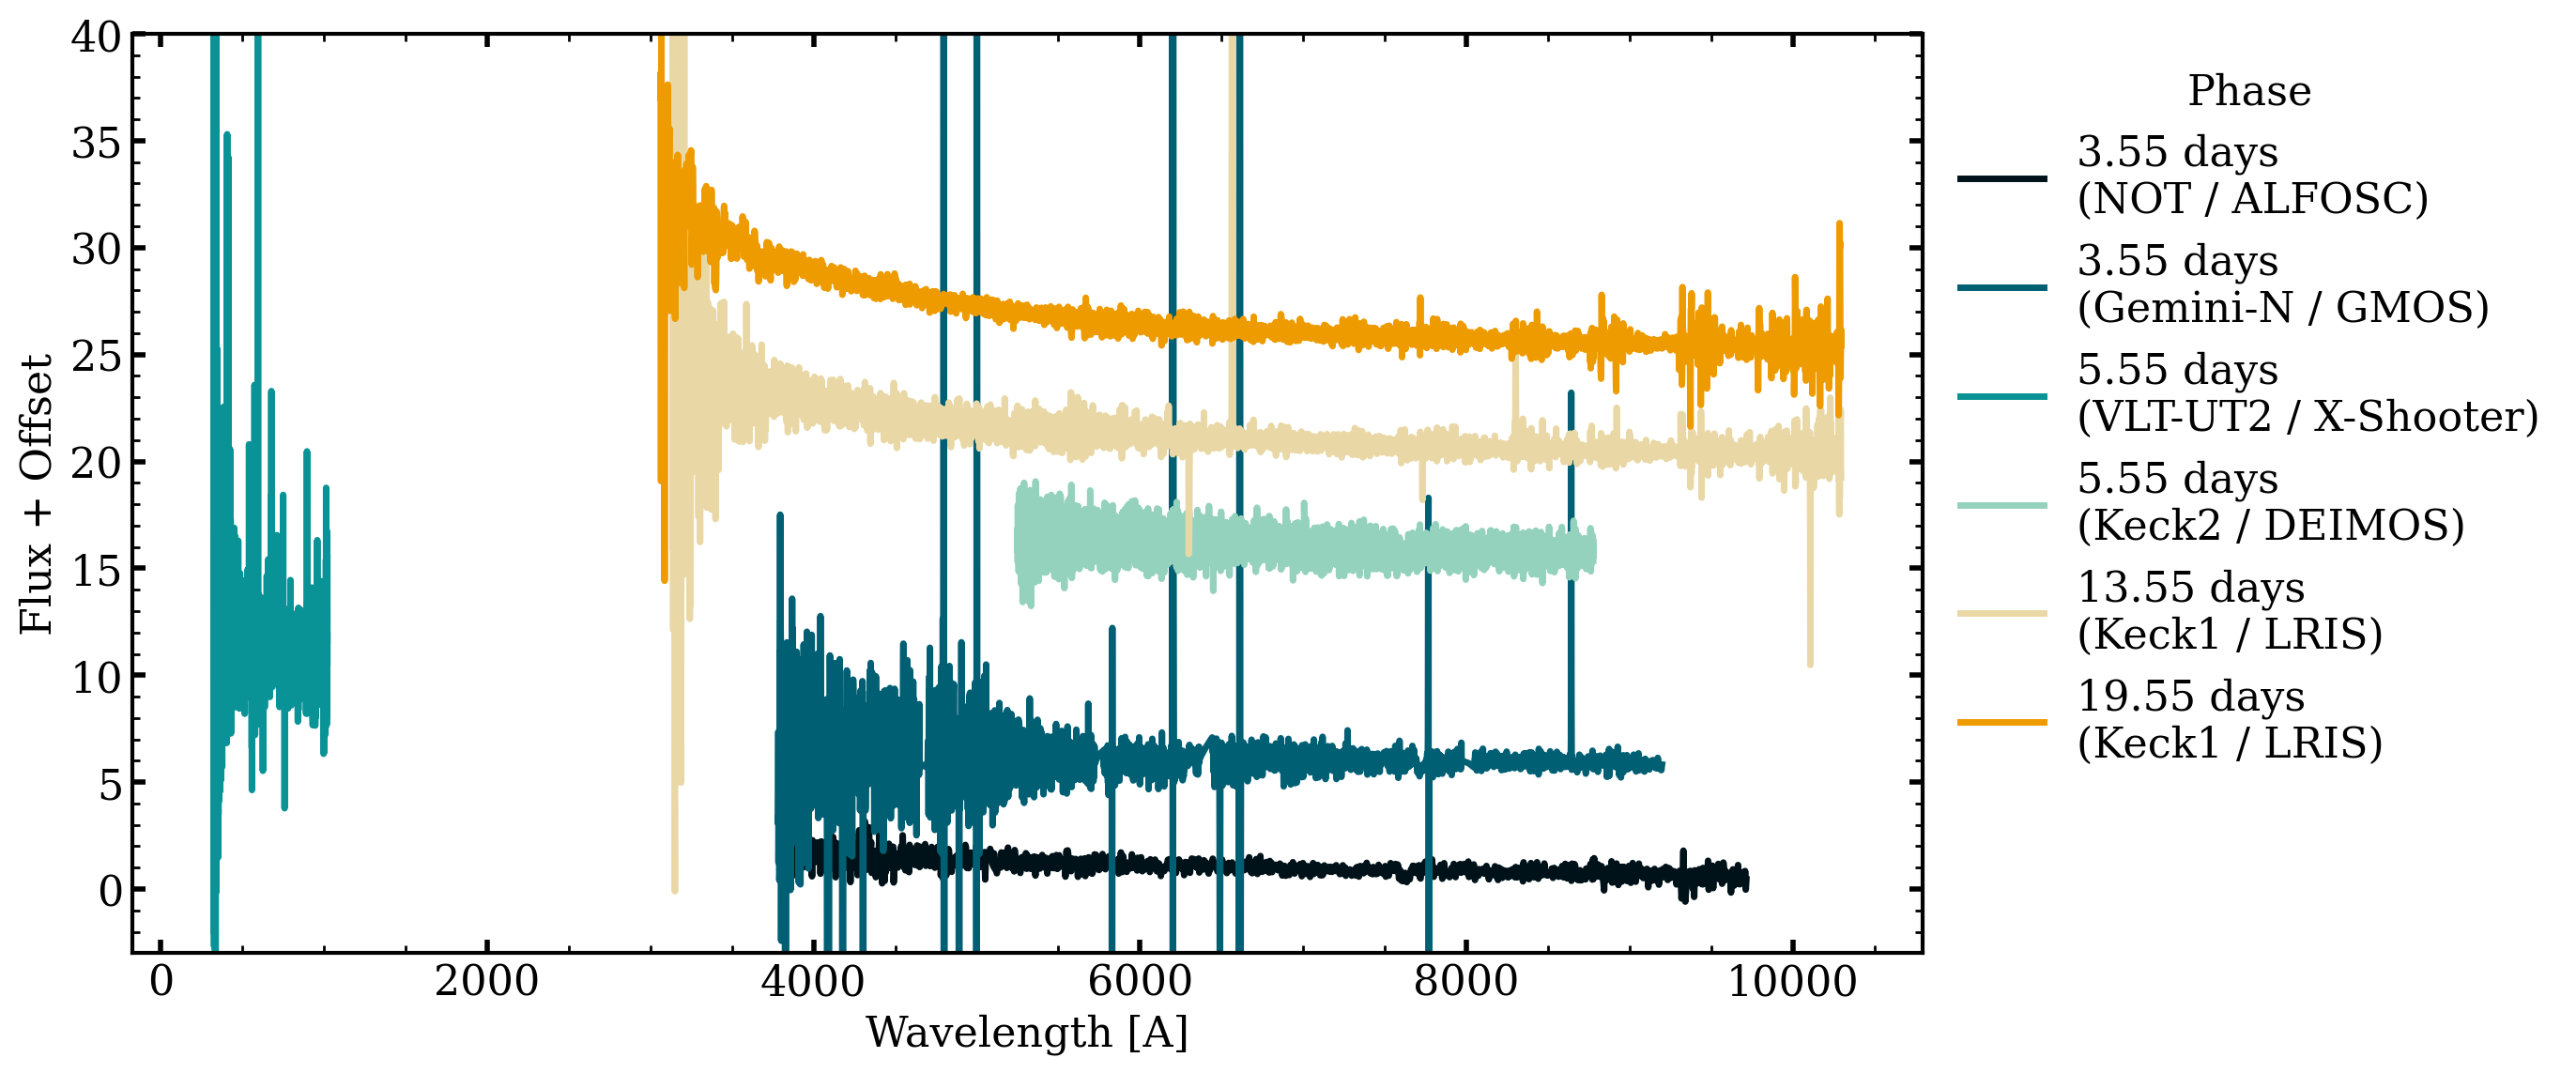

In [4]:
# get the 22cmc discovery date
disc_date = t.get_discovery_date().mjd

# sort the metadata dataframe by the date
spec_meta["phase"] = [Time(d).mjd-disc_date for d in spec_meta["Obs-date (UT)"]]
spec_meta = spec_meta.sort_values("phase")

# then plot
fig, ax = plt.subplots(figsize=(14, 6))
for offset, (idx,row) in enumerate(spec_meta.iterrows()):
    spec_df = spec[idx]
    norm = spec_df.flux.median()
    ax.plot(spec_df.wave, (spec_df.flux/norm)+5*offset, marker="none", label=f"{row.phase:.2f} days\n({row['Tel / Inst']})")

ax.set_ylim(-3, 40)
ax.legend(title="Phase", bbox_to_anchor=(1,1), loc="upper left")
ax.set_ylabel("Flux + Offset")
ax.set_xlabel("Wavelength [A]")

### Querying WISeREP for transients *not* in OTTER

The `Transient.get_wiserep_spec` method is just a wrapper on the `DataFinder.query_wiserep` method, so we can use that for a transient not currently in OTTER. As an example, consider the Type IIb supernova SN 2025ulz. 

In [5]:
datafinder = DataFinder(
    ra = 237.9758159, 
    dec = +30.9023752,
    ra_units = "deg",
    dec_units = "deg",
    name = "2025ulz" # this should be the IAU Name! Otherwise you'll get an error
)

datafinder.query_wiserep()

(   Spec. ID  Obj. ID Obj. IAU Name         Obj. Alt. Name/s Obj Family Type  \
 0     87945    28864    SN 2025ulz  ZTF25abjmnps, SN2025ulz              SN   
 1     88934    28864    SN 2025ulz  ZTF25abjmnps, SN2025ulz              SN   
 
   Obj Type  Redshift           Obs-date (UT)  Phase/s      Tel / Inst  ...  \
 0    SN II    0.0848  2025-08-24 00:03:40.00      NaN  VLT-UT4 / MUSE  ...   
 1    SN II    0.0848  2025-08-30 02:32:55.00      NaN  MMT / BINOSPEC  ...   
 
    Public End Prop. Period Reporter/s Publish Contrib  \
 0       Y              NaN        NaN     NaN     NaN   
 1       Y              NaN        0.0     NaN     NaN   
 
                                  Remarks  Created by   Creation date (UT)  \
 0  [TNS reporting group: 120 - ENGRAVE ]    TNS_Bot1  2025-08-25 08:30:06   
 1                                    NaN  Noah Franz  2025-10-26 18:51:24   
 
    Modified by Last modified date (UT)  
 0     TNS_Bot1     2025-11-06 11:25:14  
 1   Noah Franz     202